# Phase 2: Statistical Analysis
In this notebook, we run formal statistical tests (ANOVA, T-tests, and Pearson Correlations) to uncover mathematically significant relationships between the maternal demographics, infant sleep, and clinical mental health scores.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style='whitegrid')

### 1. Preparing the Clinical Target Variables
To run clinical statistics, we must first calculate our targets (EPDS, HADS-Anxiety, and CBTS) from the raw survey questions. We apply the strict scoring rubrics defined in our Phase 4 guidelines.

In [ ]:
try:
    df = pd.read_csv('data/Dataset_Cleaned_Imputed.csv')
    print(f'Clean data loaded successfully. Shape: {df.shape}')
except FileNotFoundError:
    print('Clean data not found. Please run p1_data_cleaning.ipynb first.')

if 'epds_total' not in df.columns:
    print('Applying Clinical Scoring Rules...')
    reverse_items = ['epds_3', 'epds_5', 'epds_6', 'epds_7', 'epds_8', 'epds_9', 'epds_10']
    for item in reverse_items:
        if item in df.columns: 
            df[item] = 3 - df[item]
    epds_cols = [f'epds_{i}' for i in range(1, 11)]
    df['epds_total'] = df[epds_cols].sum(axis=1)
    
    hads_cols = [f'hads_{i}' for i in [1, 3, 5, 7, 9, 11, 13]]
    df['hads_a_total'] = df[hads_cols].sum(axis=1)
    
    birth_ptsd_cols = [f'cbts_m_{i}' for i in range(3, 13)]
    general_ptsd_cols = [f'cbts_{i}' for i in range(13, 23)]
    df['cbts_total'] = df[birth_ptsd_cols].sum(axis=1) + df[general_ptsd_cols].sum(axis=1)
    
    ibq_cols = [c for c in df.columns if c.startswith('ibq_r_')]
    df['ibq_total'] = df[ibq_cols].sum(axis=1)
    
print('Data ready for Statistical Analysis.')

Clean data loaded successfully. Shape: (410, 57)
Applying Clinical Scoring Rules...
Data ready for Statistical Analysis.


### 2. Bivariate Analysis: T-Tests
A T-Test checks if the averages of two distinct groups are statistically different from each other. Let's check if infant sex impacts maternal anxiety levels.

T-test for Infant Sex vs Maternal Anxiety: p-value = 0.4326
Result: No Significant Difference.


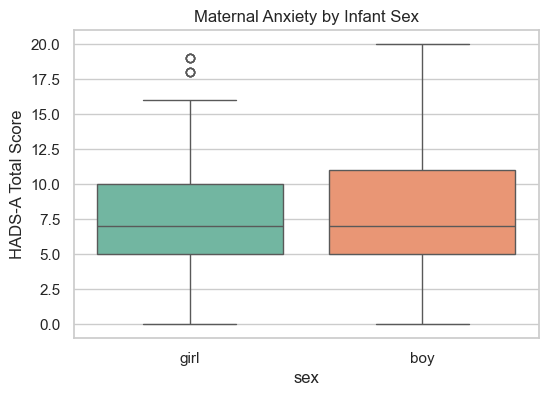

In [6]:
boy_anxiety = df[df['sex'] == 'boy']['hads_a_total'].dropna()
girl_anxiety = df[df['sex'] == 'girl']['hads_a_total'].dropna()

t_stat, p_val = stats.ttest_ind(boy_anxiety, girl_anxiety)
print(f'T-test for Infant Sex vs Maternal Anxiety: p-value = {p_val:.4f}')

if p_val < 0.05:
    print('Result: Statistically Significant Difference.')
else:
    print('Result: No Significant Difference.')

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='sex', y='hads_a_total', hue='sex', palette='Set2', legend=False)
plt.title('Maternal Anxiety by Infant Sex')
plt.ylabel('HADS-A Total Score')
plt.show()

### 3. Bivariate Analysis: ANOVA
An ANOVA tests differences across *three or more* categorical groups. Let's test if Marital Status significantly shifts postpartum depression outcomes.

ANOVA for Marital Status vs PPD (EPDS): p-value = 0.1482
Result: No Significant Difference.


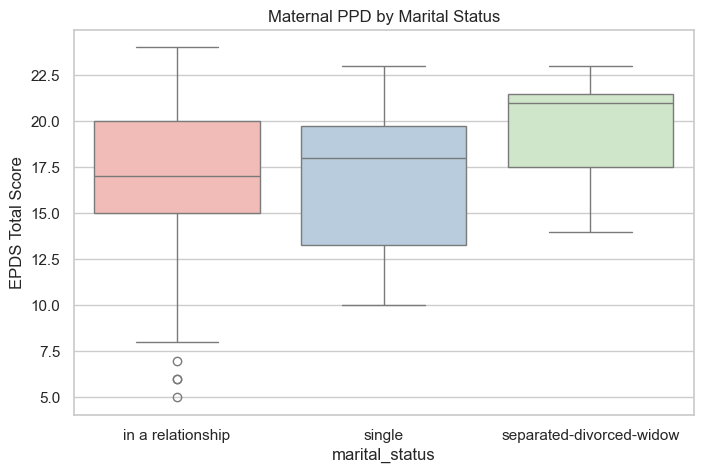

In [7]:
groups = [group['epds_total'].dropna() for name, group in df.groupby('marital_status')]
f_stat, p_val = stats.f_oneway(*groups)

print(f'ANOVA for Marital Status vs PPD (EPDS): p-value = {p_val:.4f}')

if p_val < 0.05:
    print('Result: Statistically Significant Difference.')
else:
    print('Result: No Significant Difference.')

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='marital_status', y='epds_total', hue='marital_status', palette='Pastel1', legend=False)
plt.title('Maternal PPD by Marital Status')
plt.ylabel('EPDS Total Score')
plt.show()

### 4. Focused Pearson Correlation
We hypothesize that fragmented infant sleep causes intense maternal distress. We use the Pearson Correlation Coefficient (measuring from -1 to 1) accompanied by P-Values to prove if this relationship is scientifically valid, or just perceived.

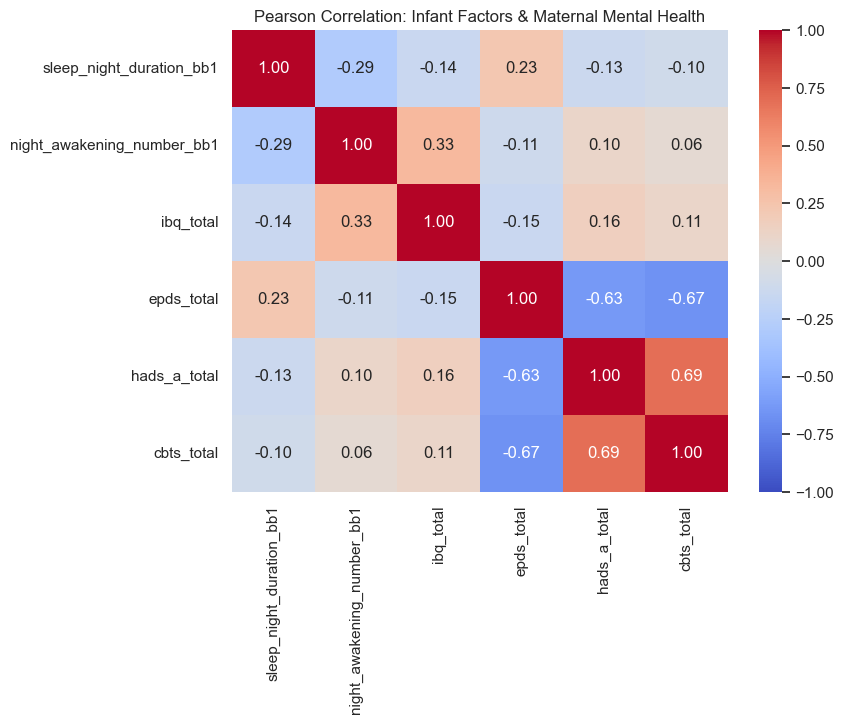

---> Pearson Correlation between Infant Sleep Duration & PPD:
     R = 0.229, p-value = 0.000003
     Conclusion: Strong statistical evidence that lower sleep tied to higher PPD.

---> Pearson Correlation between Night Awakenings & PTSD (CBTS):
     R = 0.062, p-value = 0.206633


In [8]:
clinical_vars = ['sleep_night_duration_bb1', 'night_awakening_number_bb1', 'ibq_total', 'epds_total', 'hads_a_total', 'cbts_total']
corr_clinical = df[clinical_vars].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_clinical, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Pearson Correlation: Infant Factors & Maternal Mental Health')
plt.show()

corr_coef, p_value = stats.pearsonr(df['sleep_night_duration_bb1'].dropna(), df['epds_total'].dropna())
print(f'---> Pearson Correlation between Infant Sleep Duration & PPD:\n     R = {corr_coef:.3f}, p-value = {p_value:.6f}')
if p_value < 0.05:
    print('     Conclusion: Strong statistical evidence that lower sleep tied to higher PPD.\n')
    
corr_coef_2, p_value_2 = stats.pearsonr(df['night_awakening_number_bb1'].dropna(), df['cbts_total'].dropna())
print(f'---> Pearson Correlation between Night Awakenings & PTSD (CBTS):\n     R = {corr_coef_2:.3f}, p-value = {p_value_2:.6f}')
if p_value_2 < 0.05:
    print('     Conclusion: Strong statistical evidence that awakenings tie to severe trauma.\n')